# Market size: how many women live where

This notebook builds and checks the **market size** half of the market model: how many potential
customers live in each part of the UAE. The other halves (who can reach whom, and which salons
compete) come in later notebooks. Data: `data/seed/v3/cells.csv`, built by
`scripts/build_cells.py`; assumptions in `data/scenarios/baseline.yaml`; sources in
`data/seed/v3/SOURCES.md`.

## 1. Model structure, and why

**The question.** For each Bedashing lounge: how big is the market it can serve, how much of it
does it capture against nearby competitors, and how much is left?

**The structure.**

1. **Market size per ~2 km grid cell** = women aged 15+ living there (this notebook).
2. **Catchment** = the cells within a 15-minute drive of the lounge (the medium travel-time
   assumption; 10 and 20 minutes are the low/high checks).
3. **Competitors** = every salon within a 30-minute drive of the lounge, i.e. 2x the travel time.
   That bound is exact, not a guess: a salon that a catchment resident can reach within 15 minutes
   is at most 15 + 15 = 30 minutes from the lounge.
4. **Each cell's women are split among every salon that can reach that cell** (inside the cell's
   own 15-minute drive), in proportion to the salons' lifetime Google review counts.
5. **A lounge's captured market** = the sum of its slices across its catchment cells. **Headroom**
   = its catchment's women minus what it captures.

**Why these choices.**

| Choice | Why | Rejected alternative |
|---|---|---|
| ~2 km grid cells | OSM neighbourhoods are patchy (Dubai's cover 66% of women, Sharjah's are whole towns, Fujairah has none). A grid covers everything the same way, and cells still carry an OSM name for display | Official communities: only Dubai publishes them with population |
| Split each **cell** among the salons that reach it | Shares in each cell add up to 1, so two nearby lounges can't both claim the same women; their overlap *is* cannibalisation | Lounge share = its reviews ÷ all reviews within 30 min: simpler, but biased low, because a salon 28 min away would compete for the whole catchment |
| Isochrones only for catchment cells | Only those cells feed a lounge's numbers; ~100 drive-time requests instead of ~475 for all 2,373 cells | Every populated cell in the UAE |
| Women **15+**, not all residents | Salon customers are adult and teenage women | Total population x a female share |
| Review count as the share weight | Revealed preference: more customers leave more reviews | Equal shares per salon (the old "fair share"), which treats a 20-review salon like a 2,000-review one |

**What the model can't see** (stated in the README): reviews are lifetime totals (older salons
look bigger); chains likely push for more reviews than independents; no distance decay inside
the 15 minutes; home-service salons; income and nationality mix; malls drawing from further away.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from matplotlib.patches import Patch, Rectangle

from scripts.build_cells import women_15plus
from src.features.assign import haversine_km

pd.set_option("display.width", 140)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.2, "grid.color": "#888", "axes.edgecolor": "#999", "font.size": 9})
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#9e9e9e"

V3 = ROOT / "data/seed/v3"
cells = pd.read_csv(V3 / "cells.csv")
emirates = pd.read_csv(V3 / "emirates.csv").set_index("emirate")
gender = pd.read_csv(V3 / "dubai_community_gender.csv")
branches = pd.read_csv(V3 / "branches.csv")
A = yaml.safe_load(open(ROOT / "data/scenarios/baseline.yaml"))["assumptions"]
SHARE = A["worker_housing_female_share"]


women = lambda cells, s: women_15plus(cells, emirates, s)


for level, s in SHARE.items():
    cells[f"women_{level}"] = women(cells, s)
print(f"{len(cells):,} cells; worker-housing female share: {SHARE}")

2,373 cells; worker-housing female share: {'low': 0.01, 'medium': 0.055, 'high': 0.15}


## 2. The assumptions this notebook uses

| # | Assumption | Value | Evidence |
|---|---|---|---|
| 1 | Population per 100 m pixel | WorldPop 2025 (R2025A, constrained), ages 15+ | The only source covering every emirate with one method; CC BY 4.0 |
| 2 | WorldPop's sex split is unusable as-is | We keep its adults, redo the split | Every UAE pixel is exactly 33.6% female (section 3) |
| 3 | Worker housing = OSM industrial land use | Adults inside `landuse=industrial` | Names don't work: Al Qusais "Industrial" is 42-48% female (section 4) |
| 4 | Female share in worker housing | low 1% / **medium 5.5%** / high 15% | 13 Dubai labour-camp communities, DSC 2022: 0.1-27%, 5.5% population-weighted (section 4) |
| 5 | Female share elsewhere | Rebalanced per emirate so the emirate's female total stays WorldPop's | Keeps totals honest; lands near the 43-54% measured in residential Dubai (section 5) |
| 6 | Cell size and floor | 0.02° (~2.2 x 2.0 km), cells with ≥ 500 adults | Finer than a 15-min catchment (~8 km across); the floor drops desert and farms but keeps 94% of adults |
| 7 | Travel time | 10 / **15** / 20 min | BrightLocal 2014 and retail trade-area practice (see SOURCES.md) |

## 3. WorldPop: totals look right, the sex split doesn't

In [2]:
e = emirates.copy()
e["worker_share_of_adults"] = e.worker_adults / e.adults
e["female_share_worldpop"] = e.women_worldpop / e.adults
tot = e.sum(numeric_only=True)
print(f"UAE adults 15+: {tot.adults:,.0f}; WorldPop women 15+: {tot.women_worldpop:,.0f} "
      f"({tot.women_worldpop / tot.adults:.1%})")
print("Official context: UAE 2025 population 11.35M, 36% female (all ages); Dubai 3.66M (DSC, 2023).")
e.round(3)

UAE adults 15+: 9,417,874; WorldPop women 15+: 3,161,822 (33.6%)
Official context: UAE 2025 population 11.35M, 36% female (all ages); Dubai 3.66M (DSC, 2023).


,adults,women_worldpop,worker_adults,worker_share_of_adults,female_share_worldpop
emirate,,,,,
Abu Dhabi,3208240,1077088,282476,0.088,0.336
Ajman,473633,159011,8160,0.017,0.336
Dubai,3036038,1019276,395192,0.130,0.336
Fujairah,296378,99502,26200,0.088,0.336
Ras Al Khaimah,475191,159534,31079,0.065,0.336
Sharjah,1818178,610409,151972,0.084,0.336
Umm Al Quwain,110216,37002,1828,0.017,0.336


In [3]:
share = cells.women_worldpop / cells.adults
print(f"WorldPop female share across {len(cells):,} cells: min {share.min():.3f}, max {share.max():.3f}")
print("One national ratio everywhere: Jebel Ali Industrial is 'as female' as Mirdif.")

WorldPop female share across 2,373 cells: min 0.335, max 0.337
One national ratio everywhere: Jebel Ali Industrial is 'as female' as Mirdif.


## 4. Calibration: what labour-camp areas really look like
Dubai Statistics Center's 2022 community estimates (via citypopulation.de) include the sex split.
We fetched the 19 industrial-named communities and 4 residential ones.

labour-camp areas: 13; female share 0.1%-27.0%, median 3.5%, population-weighted 5.5%


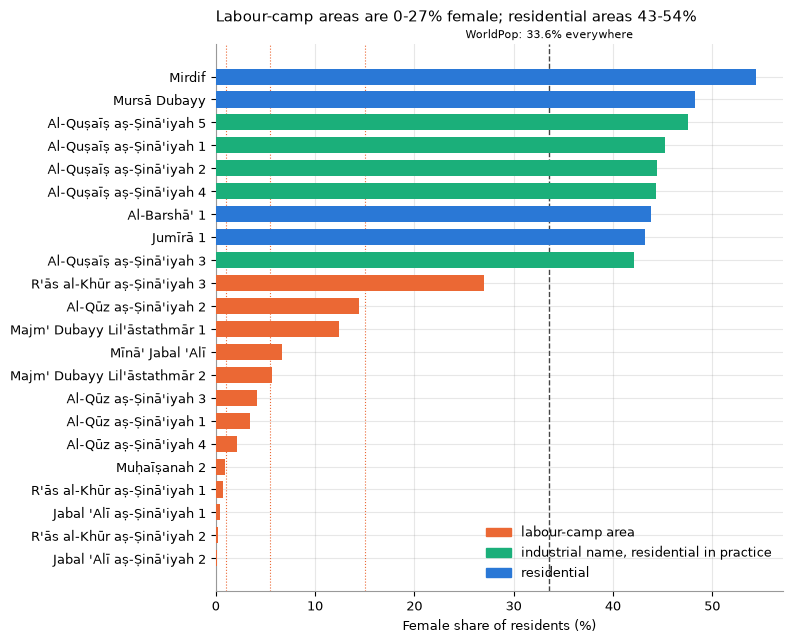

In [4]:
g = gender.dropna(subset=["female_share"]).copy()
g["group"] = np.where(g.kind == "residential", "residential",
                      np.where(g.female_share > 0.35, "industrial name, residential in practice", "labour-camp area"))
camps = g[g.group == "labour-camp area"]
weighted = camps.females.sum() / (camps.males + camps.females).sum()
print(f"labour-camp areas: {len(camps)}; female share {camps.female_share.min():.1%}-{camps.female_share.max():.1%}, "
      f"median {camps.female_share.median():.1%}, population-weighted {weighted:.1%}")
s = g.sort_values("female_share")
colors = {"labour-camp area": ORANGE, "industrial name, residential in practice": AQUA, "residential": BLUE}
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(s.name, s.female_share * 100, color=[colors[x] for x in s.group], height=0.7, zorder=3)
ax.axvline(33.6, color="#444", ls="--", lw=1)
ax.text(33.6, 1.01, "WorldPop: 33.6% everywhere", transform=ax.get_xaxis_transform(), ha="center", fontsize=8)
for lvl, v in SHARE.items():
    ax.axvline(v * 100, color=ORANGE, lw=0.8, ls=":")
ax.set_xlabel("Female share of residents (%)")
ax.set_title("Labour-camp areas are 0-27% female; residential areas 43-54%", loc="left", pad=16)
ax.legend(handles=[Patch(color=c, label=k) for k, c in colors.items()], loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

## 5. Validation: does the sex-ratio correction land near the measured ratios?

**What "measured" means here.** The Dubai Statistics Center (DSC), Dubai's official statistics
office, publishes population estimates per community with a male/female breakdown (estimate year
2022). We read them from citypopulation.de, which republishes DSC's figures community by
community (`data/seed/v3/dubai_community_gender.csv`, 23 communities: the 18 with "Industrial",
"Investment Park" or "Port" in the name, Muhaisnah 2 (the Sonapur labour-camp district), and 4
residential ones as a baseline). "Measured female share" = females ÷ (males + females) in that community. So these are
**official estimates, not a survey or census count we ran**, and they are independent of WorldPop
and OSM, which is what makes them a fair check. Two caveats: they cover **all ages** while the
model counts women **15+** (minor: labour camps have almost no children, and in residential
areas children are roughly half girls), and they are 2022 estimates against WorldPop 2025.
Each measured community is located by its OSM place point (`data/raw/osm/places.json`); take the cell
that contains it and compare the modelled female share (medium) with the measured one. 21 of the 22
measured communities have an OSM place point; **Muhaisnah 2 (Sonapur) doesn't**, so the largest camp
district can't be checked here. A 2 km cell mixes in its neighbours, so expect the direction to be
right, not the exact number.

In [5]:
import json

places = {(x["tags"].get("name:en") or x["tags"].get("name")): (x["lat"], x["lon"])
          for x in json.loads((ROOT / "data/raw/osm/places.json").read_text())["elements"]}
# measured community (DSC name) -> its OSM place name
pairs = {"Jabal 'Alī aṣ-Ṣinā'iyah 1": "Jabal Ali Industrial 1", "Jabal 'Alī aṣ-Ṣinā'iyah 2": "Jabal Ali Industrial 2",
         "Al-Qūz aṣ-Ṣinā'iyah 1": "Al Quoz Industrial 1", "Al-Qūz aṣ-Ṣinā'iyah 2": "Al Quoz Industrial 2",
         "Al-Qūz aṣ-Ṣinā'iyah 3": "Al Quoz Industrial 3", "Al-Qūz aṣ-Ṣinā'iyah 4": "Al Quoz Industrial 4",
         "Al-Quṣaīṣ aṣ-Ṣinā'iyah 1": "Al Qusais Industrial 1", "Al-Quṣaīṣ aṣ-Ṣinā'iyah 2": "Al Qusais Industrial 2",
         "Al-Quṣaīṣ aṣ-Ṣinā'iyah 3": "Al Qusais Industrial 3", "Al-Quṣaīṣ aṣ-Ṣinā'iyah 4": "Al Qusais Industrial 4",
         "Al-Quṣaīṣ aṣ-Ṣinā'iyah 5": "Al Qusais Industrial 5", "R'ās al-Khūr aṣ-Ṣinā'iyah 1": "Ras Al Khor Industrial 1",
         "R'ās al-Khūr aṣ-Ṣinā'iyah 2": "Ras Al Khor Ind 2", "R'ās al-Khūr aṣ-Ṣinā'iyah 3": "Ras Al Khor Industrial 3",
         "Majm' Dubayy Lil'āstathmār 1": "Dubai Investment Park 1", "Majm' Dubayy Lil'āstathmār 2": "Dubai Investment Park 2",
         "Mīnā' Jabal 'Alī": "Jebel Ali Port", "Mirdif": "Mirdif", "Mursā Dubayy": "Dubai Marina",
         "Al-Barshā' 1": "Al Barsha 1", "Jumīrā 1": "Jumeirah 1"}
measured = gender.set_index("name")
rows = []
for dsc_name, osm_name in pairs.items():
    lat, lng = places[osm_name]
    c = cells[(cells.south <= lat) & (lat < cells.north) & (cells.west <= lng) & (lng < cells.east)]
    if c.empty:
        continue
    c = c.iloc[0]
    rows.append({"community": osm_name, "group": g.set_index("name").loc[dsc_name, "group"],
                 "measured": measured.loc[dsc_name, "female_share"], "worldpop": c.women_worldpop / c.adults,
                 "modelled_medium": c.women_medium / c.adults, "cell_worker_share": c.adults_worker / c.adults})
val = pd.DataFrame(rows).set_index("community")

print("Sex ratios measured vs modelled")
val.sort_values("measured").round(3)

Sex ratios measured vs modelled


,group,measured,worldpop,modelled_medium,cell_worker_share
community,,,,,
Jabal Ali Industrial 2,labour-camp area,0.001,0.336,0.087,0.902
Ras Al Khor Ind 2,labour-camp area,0.002,0.336,0.350,0.085
Jabal Ali Industrial 1,labour-camp area,0.005,0.336,0.055,1.000
Ras Al Khor Industrial 1,labour-camp area,0.007,0.336,0.377,0.002
Al Quoz Industrial 4,labour-camp area,0.021,0.336,0.076,0.935
Al Quoz Industrial 1,labour-camp area,0.035,0.336,0.078,0.928
Al Quoz Industrial 3,labour-camp area,0.042,0.336,0.076,0.935
Dubai Investment Park 2,labour-camp area,0.057,0.336,0.358,0.061
Jebel Ali Port,labour-camp area,0.066,0.336,0.058,0.991


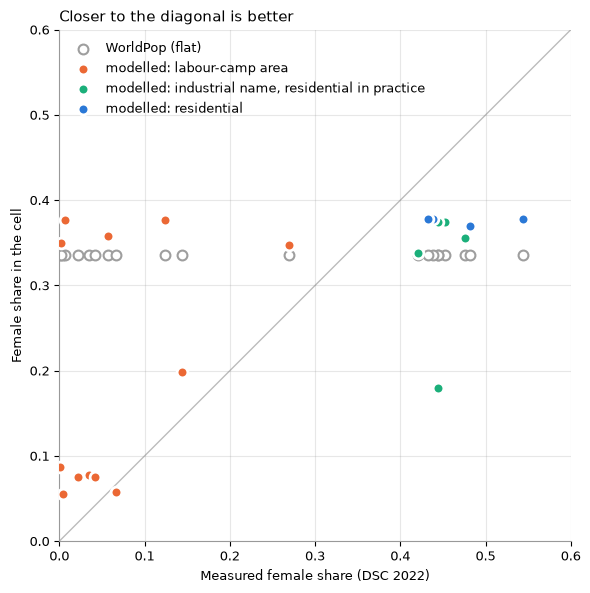

mean absolute error (21 communities): WorldPop 0.208, modelled 0.128
  labour-camp area                           n=12  WorldPop 0.271  modelled 0.140
  industrial name, residential in practice   n= 5  WorldPop 0.112  modelled 0.123
  residential                                n= 4  WorldPop 0.139  modelled 0.099


In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 0.6], [0, 0.6], color="#bbb", lw=1, zorder=1)
ax.scatter(val.measured, val.worldpop, s=50, facecolor="white", edgecolor=GREY, lw=1.5, label="WorldPop (flat)", zorder=2)
for grp, col in colors.items():
    v = val[val.group == grp]
    ax.scatter(v.measured, v.modelled_medium, s=60, color=col, edgecolor="white", lw=2, label=f"modelled: {grp}", zorder=3)
ax.set_xlabel("Measured female share (DSC 2022)")
ax.set_ylabel("Female share in the cell")
ax.set_xlim(0, 0.6); ax.set_ylim(0, 0.6); ax.set_aspect(1)
ax.set_title("Closer to the diagonal is better", loc="left")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()
mae = lambda col: (val[col] - val.measured).abs().mean()
print(f"mean absolute error ({len(val)} communities): WorldPop {mae('worldpop'):.3f}, modelled {mae('modelled_medium'):.3f}")
for grp in colors:
    v = val[val.group == grp]
    print(f"  {grp:42} n={len(v):2}  WorldPop {(v.worldpop - v.measured).abs().mean():.3f}  modelled {(v.modelled_medium - v.measured).abs().mean():.3f}")

## 6. Where the women are

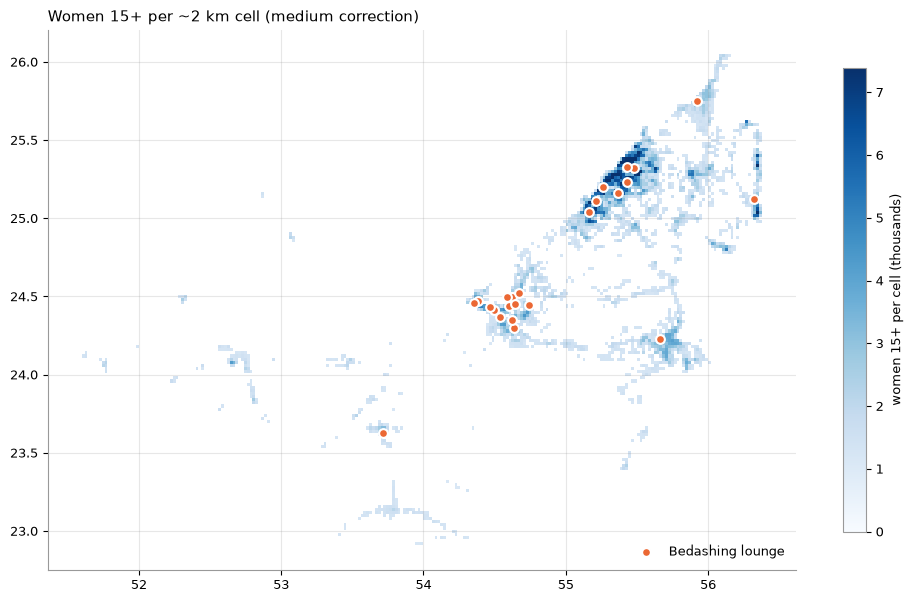

In [7]:
def cell_map(ax, df, col, title, extent=None):
    v = df[col] / 1000
    vmax = np.percentile(v, 99)
    cmap = plt.get_cmap("Blues")
    for r, x in zip(df.itertuples(), v):
        ax.add_patch(Rectangle((r.west, r.south), r.east - r.west, r.north - r.south,
                               facecolor=cmap(0.15 + 0.85 * min(x / vmax, 1)), edgecolor="none"))
    ax.scatter(branches.lng, branches.lat, s=40, color=ORANGE, edgecolor="white", lw=1.5, zorder=3, label="Bedashing lounge")
    if extent:
        ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
    else:
        ax.autoscale_view()
    ax.set_aspect(1 / 0.91)
    ax.set_title(title, loc="left")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax)); sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.6, label="women 15+ per cell (thousands)")

fig, ax = plt.subplots(figsize=(10, 8))
cell_map(ax, cells, "women_medium", "Women 15+ per ~2 km cell (medium correction)")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

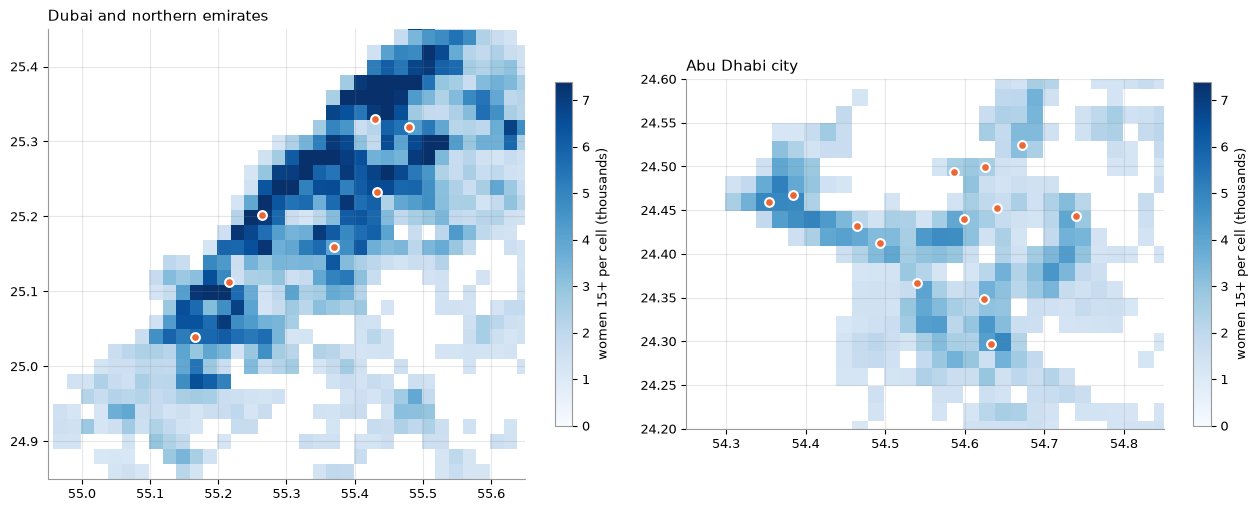

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
cell_map(axes[0], cells, "women_medium", "Dubai and northern emirates", (54.95, 55.65, 24.85, 25.45))
cell_map(axes[1], cells, "women_medium", "Abu Dhabi city", (54.25, 54.85, 24.2, 24.6))
plt.tight_layout(); plt.show()

## 7. How much does the correction change the market near each lounge?
Two counts of the same people, compared: **WorldPop as published** (every adult 33.6% female) vs
**our corrected count** (worker housing at 5.5% female, every other cell rebalanced so each
emirate's total number of women is unchanged). The correction doesn't add or remove women; it
moves them from worker-housing cells to residential ones. So a lounge surrounded by homes ends up
with *more* women nearby than WorldPop says, and one next to industrial land with *fewer*.

A preview until Task 3 computes real 15-minute catchments: women in cells within 8 km
straight-line of each lounge (TomTom 2025: the average Dubai driver covers ~7.8 km in 15 minutes).

In [9]:
rows = []
for b in branches.itertuples():
    d = cells.apply(lambda c: haversine_km(b.lat, b.lng, c.lat, c.lng), axis=1)
    near = cells[d <= 8]
    rows.append({"branch_id": b.branch_id, "emirate": b.emirate,
                 "worker_share_of_adults": near.adults_worker.sum() / near.adults.sum(),
                 "women_worldpop": near.women_worldpop.sum(),
                 **{f"women_{l}": near[f"women_{l}"].sum() for l in SHARE}})
near = pd.DataFrame(rows).set_index("branch_id")
near["change_vs_worldpop"] = near.women_medium / near.women_worldpop - 1
near.sort_values("worker_share_of_adults", ascending=False).round(3)

,emirate,worker_share_of_adults,women_worldpop,women_low,women_medium,women_high,change_vs_worldpop
branch_id,,,,,,,
mohammed-bin-zayed-city,Abu Dhabi,0.286,89406,70598.506,73196.596,78681.452,-0.181
al-maqta,Abu Dhabi,0.227,65675,55987.653,57326.031,60151.496,-0.127
jumeirah-park,Dubai,0.152,179467,175088.342,175692.832,176968.979,-0.021
zawaya-walk,Sharjah,0.133,229714,217888.908,219522.943,222972.572,-0.044
al-jada,Sharjah,0.132,216225,204734.320,206321.860,209673.335,-0.046
ministries-complex,Abu Dhabi,0.114,55547,54000.788,54214.234,54664.843,-0.024
al-taif-mall,Fujairah,0.109,44944,43825.220,43979.829,44306.224,-0.021
al-barsha,Dubai,0.082,155911,164277.530,163121.253,160680.225,0.046
mirdif-35,Dubai,0.063,196989,210662.823,208773.752,204785.714,0.060


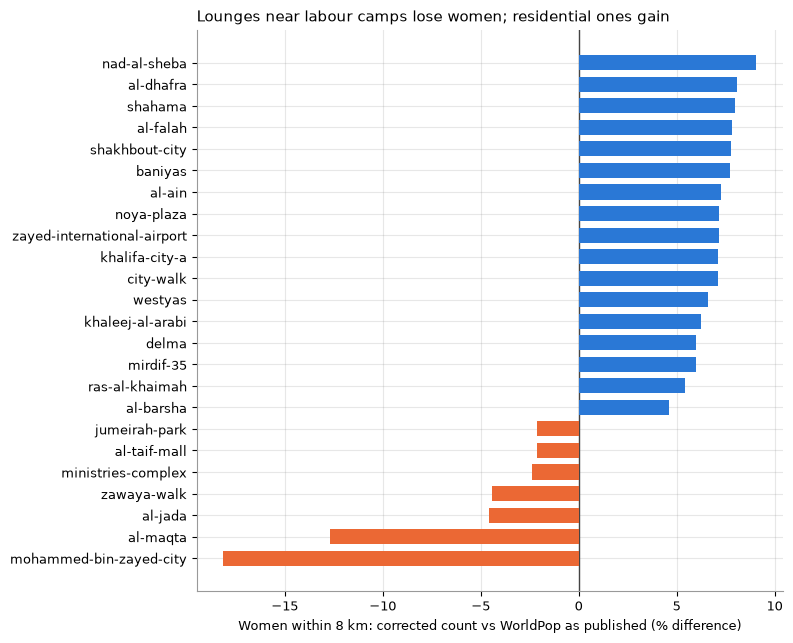

In [10]:
s = near.sort_values("change_vs_worldpop")
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(s.index, s.change_vs_worldpop * 100, color=[ORANGE if v < 0 else BLUE for v in s.change_vs_worldpop],
        height=0.7, zorder=3)
ax.axvline(0, color="#444", lw=1)
ax.set_xlabel("Women within 8 km: corrected count vs WorldPop as published (% difference)")
ax.set_title("Lounges near labour camps lose women; residential ones gain", loc="left")
plt.tight_layout(); plt.show()

## 8. Findings

**Totals are usable.** WorldPop puts 9.42M adults (15+) in the UAE; 2,373 cells with at least 500
adults hold 94% of them. Dubai has 3.04M adults and Abu Dhabi 3.21M, plausible against official
totals (UAE 11.35M people, Dubai 3.66M, all ages).

**WorldPop's sex split is flat:** every cell is 33.6% female, Jebel Ali Industrial included. Measured
reality (DSC 2022): labour-camp areas 0.1-27% (5.5% weighted by population), residential 43-54%. So
the flat ratio overstates women in camps *and* understates them in residential areas.

**The correction helps, but misses unmapped camps (validation, section 5, 21 measured communities).**
- Mean absolute error vs measured: WorldPop 0.21 → corrected 0.13. Labour-camp areas 0.27 → 0.14;
  residential 0.14 → 0.10.
- **Caught well (7 of 12 camp areas):** where OSM maps industrial land, e.g. Jebel Ali Industrial 1
  (measured 0.5% → modelled 5.5%), Al Quoz Industrial 1, 3, 4 (2-4% → ~8%), Jebel Ali Port (7% → 6%).
- **Missed:** Dubai Investment Park 1-2 and Ras Al Khor Industrial 1-2 come out at 35-38% (measured
  0.2-12%): their camps aren't mapped as industrial. Muhaisnah 2 (Sonapur, ~150k people, 0.9%
  female) has no OSM place point, so it can't be validated here, but its cells carry little
  industrial land, so it's very likely missed too.
- **One false positive:** Al Qusais Industrial 4 is 44% female but modelled at 18% (its cell is
  59% industrial land). Al Qusais "Industrial" is residential in practice, so names don't
  identify worker housing (that's why we use land use, not names).
- Because some camps aren't caught, residential cells rise only to ~38% (measured 43-54%).

**Effect near lounges (8 km preview, section 7).** Compared with WorldPop's published (flat 33.6%)
numbers, the corrected count of women within 8 km is **5-9% higher for most lounges**, because
they sit in residential areas that receive the women moved out of worker housing. Lounges next to
industrial land get **fewer**: mohammed-bin-zayed-city −18% and al-maqta −13% (Mussafah/ICAD),
al-jada and zawaya-walk −5% (Sharjah industrial areas), jumeirah-park −2%. **Mirdif-35 still
comes out +6%** although Sonapur sits next to it: Sonapur's camps aren't mapped as industrial, so
they aren't moved out, and Mirdif's market is overstated.

**Tried and rejected: OSM labour-accommodation tags as a second signal** (2026-10-08). One query
for dormitory buildings and features named "labour camp", "workers village", "staff accommodation"
returned 117 features UAE-wide, 79 after removing offices, ministries and laboratories: **none
within 3 km of Sonapur**, a handful in DIP, Mussafah and Jebel Ali. Labour housing isn't
mapped consistently in OSM, so this adds nothing. Raw file kept in `data/raw/osm/labour_accommodation.json`.